# DeconfoundingFM: structured mixture demonstration

This demonstration compares **DeconfoundingFM**, **OT-DeconfoundingFM**, and an otherwise matched **Gaussian-base flow-matching** estimator on a structured three-mode outcome distribution. The middle counterfactual mode is centered at the origin, so $N(0,I)$ directly overlaps one target cluster; the other two modes remain well separated. All target methods use a 1x64 MLP, target learning rate `3e-4`, 20,000 optimizer updates, batch size 256, and a 64-draw plug-in reservoir.


In [1]:
%matplotlib inline
from pathlib import Path
import sys

# Allow the notebook to run directly from a fresh clone before editable install.
_here = Path.cwd().resolve()
for _root in (_here, _here.parent):
    if (_root / "src" / "deconfoundingfm").exists():
        sys.path.insert(0, str(_root / "src"))
        break

import math
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import torch

from deconfoundingfm import DeconfoundingFM, DeconfoundingFMConfig
from deconfoundingfm.integrators import path_energy_midpoint

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# For this small CPU example, one thread is faster and more reproducible than
# dispatching many tiny matrix operations across a large CPU thread pool.
if DEVICE == "cpu":
    torch.set_num_threads(1)

print("device:", DEVICE)


device: cpu


## 1. Generate structured observational data


In [2]:
# Three well-separated modes carry most of the geometry of Y.
# The middle counterfactual mode is centered at the origin so that
# the standard Gaussian baseline directly overlaps one of the three modes.
TREATMENT_SHIFT = torch.tensor([0.7, 0.35])
CENTERS = torch.tensor([
    [-4.1, -4.95],
    [-0.7, -0.35],
    [ 2.7, -4.75],
])
MIXTURE_WEIGHTS = torch.tensor([0.34, 0.32, 0.34])
NOISE_SD = 0.28
X_EFFECT = 0.95
PROPENSITY_SLOPE = 3.2


def sample_structural_noise(n, device="cpu"):
    centers = CENTERS.to(device)
    weights = MIXTURE_WEIGHTS.to(device)
    component = torch.multinomial(weights, n, replacement=True)
    return centers[component] + NOISE_SD * torch.randn(n, 2, device=device)


def sample_outcome(x, a):
    x = x.reshape(-1)
    a = a.reshape(-1)
    structural = sample_structural_noise(len(x), x.device)
    x_shift = torch.stack([
        X_EFFECT * x,
        0.22 * torch.sin(math.pi * x),
    ], dim=1)
    return structural + x_shift + a[:, None] * TREATMENT_SHIFT.to(x.device)


n = 1_000
X = 2 * torch.rand(n, 1) - 1
propensity = torch.sigmoid(PROPENSITY_SLOPE * X[:, 0])
A = torch.bernoulli(propensity)
Y = sample_outcome(X, A)

# Synthetic reference samples from P(Y(1)); never supplied to the fitted models.
n_reference = 2_500
X_reference = 2 * torch.rand(n_reference, 1) - 1
Y1_reference = sample_outcome(X_reference, torch.ones(n_reference))
Y1_observed = Y[A == 1]

print(f"n = {n:,}")
print(f"arm counts: A=0: {(A == 0).sum().item()}, A=1: {(A == 1).sum().item()}")
print(f"true propensity range in this sample: [{propensity.min():.3f}, {propensity.max():.3f}]")
print("target mode centers ignoring X shift:")
print(CENTERS + TREATMENT_SHIFT)


n = 1,000
arm counts: A=0: 512, A=1: 488
true propensity range in this sample: [0.039, 0.961]
target mode centers ignoring X shift:
tensor([[-3.4000, -4.6000],
        [ 0.0000,  0.0000],
        [ 3.4000, -4.4000]])


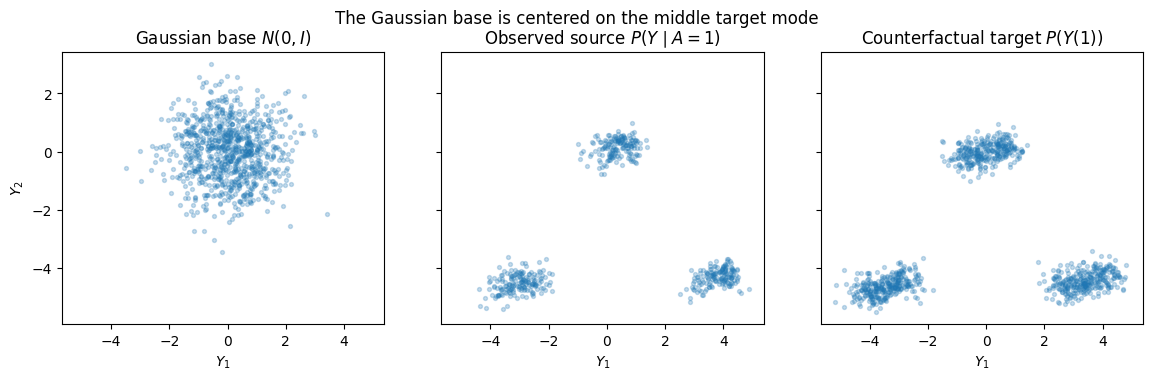

In [3]:
gaussian_base = torch.randn(900, 2)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True)
axes[0].scatter(gaussian_base[:, 0], gaussian_base[:, 1], s=8, alpha=0.25)
axes[0].set_title(r"Gaussian base $N(0,I)$")
axes[1].scatter(Y1_observed[:, 0], Y1_observed[:, 1], s=8, alpha=0.25)
axes[1].set_title(r"Observed source $P(Y\mid A=1)$")
axes[2].scatter(Y1_reference[:900, 0], Y1_reference[:900, 1], s=8, alpha=0.25)
axes[2].set_title(r"Counterfactual target $P(Y(1))$")
for ax in axes:
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel(r"$Y_2$")
fig.suptitle("The Gaussian base is centered on the middle target mode")
plt.tight_layout()
plt.show()


## 2. Fit the nuisance models and DeconfoundingFM

The first fit estimates the propensity and conditional outcome nuisances from the observational data. The target flow then receives an **exact budget of 20,000 optimizer updates** via `iterations=20_000`. The following OT and Gaussian comparisons reuse these same fitted nuisances.


In [4]:
CHECKPOINT_STEPS = [250, 500, 1_000, 2_000, 5_000, 10_000, 15_000, 20_000]

config = DeconfoundingFMConfig(
    device=DEVICE,
    seed=SEED,
    coupling="independent",
    architecture="mlp",
    base_kind="empirical",
    hidden=64,
    layers=1,
    batch_size=256,
    lr=3e-4,
    iterations=20_000,
    ode_steps=20,
    nuisance_hidden=64,
    nuisance_layers=1,
    nuisance_batch_size=512,
    nuisance_lr=1e-3,
    nuisance_epochs=120,
    nuisance_ode_steps=14,
    nuisance_base_kind="empirical",
    propensity_trees=100,
    propensity_max_depth=4,
    plugin_reservoir=64,
    plugin_batch=4,
    # Minibatch EOT settings used in the public demo.
    eot_iterations=20,
    eot_source_batch=128,
    eot_epsilon_scale=0.1,
)

decfm = DeconfoundingFM(config).fit(
    X, A, Y, verbose=False, checkpoint_steps=CHECKPOINT_STEPS
)
print("DeconfoundingFM iterations:", decfm.diagnostics()["training_iterations"])


DeconfoundingFM iterations: 20000


## 3. Fit OT-DeconfoundingFM

`coupling="ot"` activates the package's minibatch **entropic optimal-transport** conditional. It uses the same observational base, target architecture, optimization budget, propensity model, and conditional outcome model as DeconfoundingFM above; only the coupling is changed.


In [5]:
ot_config = replace(config, coupling="ot")
ot_decfm = DeconfoundingFM(
    ot_config,
    outcome_model=decfm.outcome_model,
    propensity_model=decfm.propensity_model,
).fit(
    X, A, Y, verbose=False, checkpoint_steps=CHECKPOINT_STEPS
)

print("OT-DeconfoundingFM iterations:", ot_decfm.diagnostics()["training_iterations"])


OT-DeconfoundingFM iterations: 20000


## 4. Gaussian-base comparison

The baseline again uses the **same debiased target objective and the same fitted nuisances**, but replaces the empirical source $P(Y\mid A=a)$ by $N(0,I)$. $N(0,I)$ is deliberately centered on the middle target mode. This gives Gaussian-base FM a favorable initialization while leaving the other two target modes well separated.


In [6]:
gaussian_config = replace(config, base_kind="gaussian", coupling="independent")
gaussian_fm = DeconfoundingFM(
    gaussian_config,
    outcome_model=decfm.outcome_model,
    propensity_model=decfm.propensity_model,
).fit(
    X, A, Y, verbose=False, checkpoint_steps=CHECKPOINT_STEPS
)

print("Gaussian-base FM iterations:", gaussian_fm.diagnostics()["training_iterations"])


Gaussian-base FM iterations: 20000


In [7]:
@torch.no_grad()
def sliced_w2(x, y, n_projections=128, seed=123):
    """Deterministic sliced-W2 diagnostic for this 2D demonstration."""
    x = x.detach().cpu()
    y = y.detach().cpu()
    n = min(len(x), len(y))
    x, y = x[:n], y[:n]
    generator = torch.Generator().manual_seed(seed)
    directions = torch.randn(n_projections, x.shape[1], generator=generator)
    directions = directions / directions.norm(dim=1, keepdim=True)
    xp = (x @ directions.T).sort(dim=0).values
    yp = (y @ directions.T).sort(dim=0).values
    return torch.sqrt(((xp - yp) ** 2).mean()).item()


n_eval = 1_200
y_ref_eval = Y1_reference[:n_eval].cpu()

# Fix the starting samples once so every checkpoint is evaluated on exactly
# the same empirical or Gaussian source sample.
source_generator = torch.Generator().manual_seed(999)
source_idx = torch.randint(len(Y1_observed), (n_eval,), generator=source_generator)
y_source_eval = Y1_observed[source_idx].cpu()

gaussian_generator = torch.Generator().manual_seed(1001)
z_gaussian_eval = torch.randn(n_eval, 2, generator=gaussian_generator)

y_decfm = decfm.transform(y_source_eval, a=1).cpu()
y_ot = ot_decfm.transform(y_source_eval, a=1).cpu()
y_gaussian = gaussian_fm.transform(z_gaussian_eval, a=1).cpu()

sw2_source = sliced_w2(y_source_eval, y_ref_eval)
sw2_decfm = sliced_w2(y_decfm, y_ref_eval)
sw2_ot = sliced_w2(y_ot, y_ref_eval)
sw2_gaussian = sliced_w2(y_gaussian, y_ref_eval)

print(f"SW2 observed source       -> target: {sw2_source:.3f}")
print(f"SW2 DeconfoundingFM       -> target: {sw2_decfm:.3f}")
print(f"SW2 OT-DeconfoundingFM    -> target: {sw2_ot:.3f}")
print(f"SW2 Gaussian-base FM      -> target: {sw2_gaussian:.3f}")


SW2 observed source       -> target: 0.432
SW2 DeconfoundingFM       -> target: 0.354
SW2 OT-DeconfoundingFM    -> target: 0.280
SW2 Gaussian-base FM      -> target: 0.478


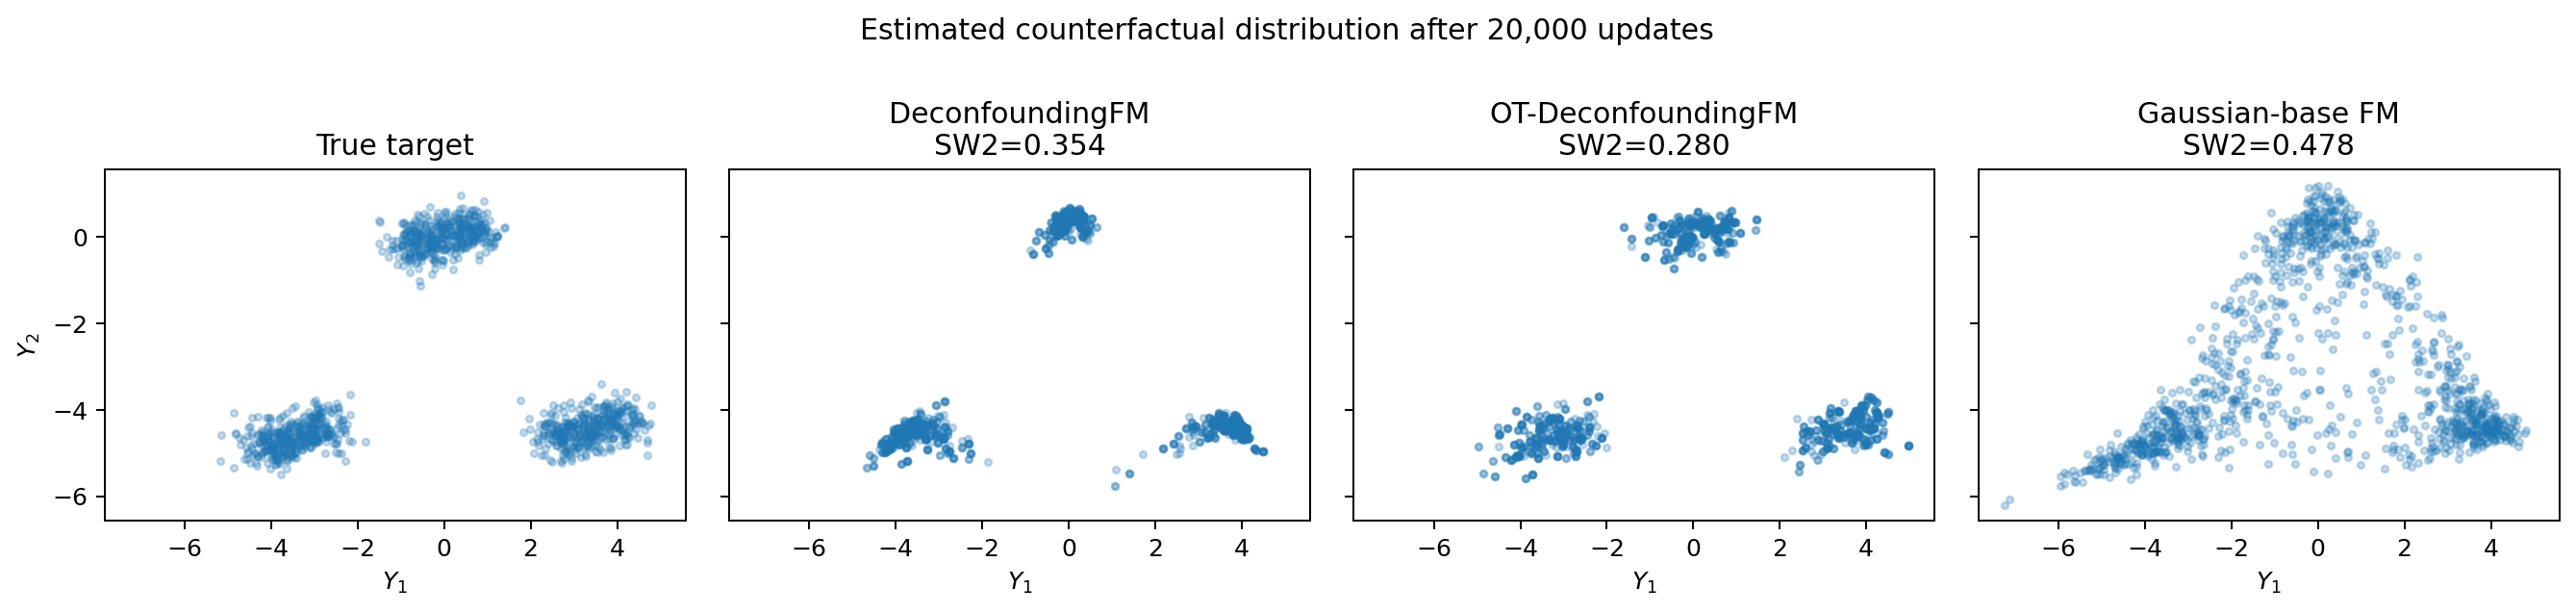

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True, sharey=True)
items = [
    (y_ref_eval, "True target"),
    (y_decfm, f"DeconfoundingFM\nSW2={sw2_decfm:.3f}"),
    (y_ot, f"OT-DeconfoundingFM\nSW2={sw2_ot:.3f}"),
    (y_gaussian, f"Gaussian-base FM\nSW2={sw2_gaussian:.3f}"),
]
for ax, (samples, title) in zip(axes, items):
    ax.scatter(samples[:, 0], samples[:, 1], s=8, alpha=0.25)
    ax.set_title(title)
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel(r"$Y_2$")
fig.suptitle("Estimated counterfactual distribution for treatment arm 1")
plt.tight_layout()
plt.show()


## 5. SW2 convergence over optimizer updates

The target models were snapshotted during the **same continuous 20,000-update run**. Each checkpoint is evaluated using the same fixed starting samples and the same reference sample, so the curves reflect optimization rather than Monte Carlo changes in evaluation.


updates      DeconfoundingFM   OT-DeconfoundingFM   Gaussian-base FM
   250         0.348              0.389              1.609
   500         0.306              0.339              0.963
 1,000         0.303              0.299              0.963
 2,000         0.309              0.292              0.970
 5,000         0.305              0.294              0.842
10,000         0.344              0.276              0.589
15,000         0.336              0.277              0.511
20,000         0.354              0.280              0.478


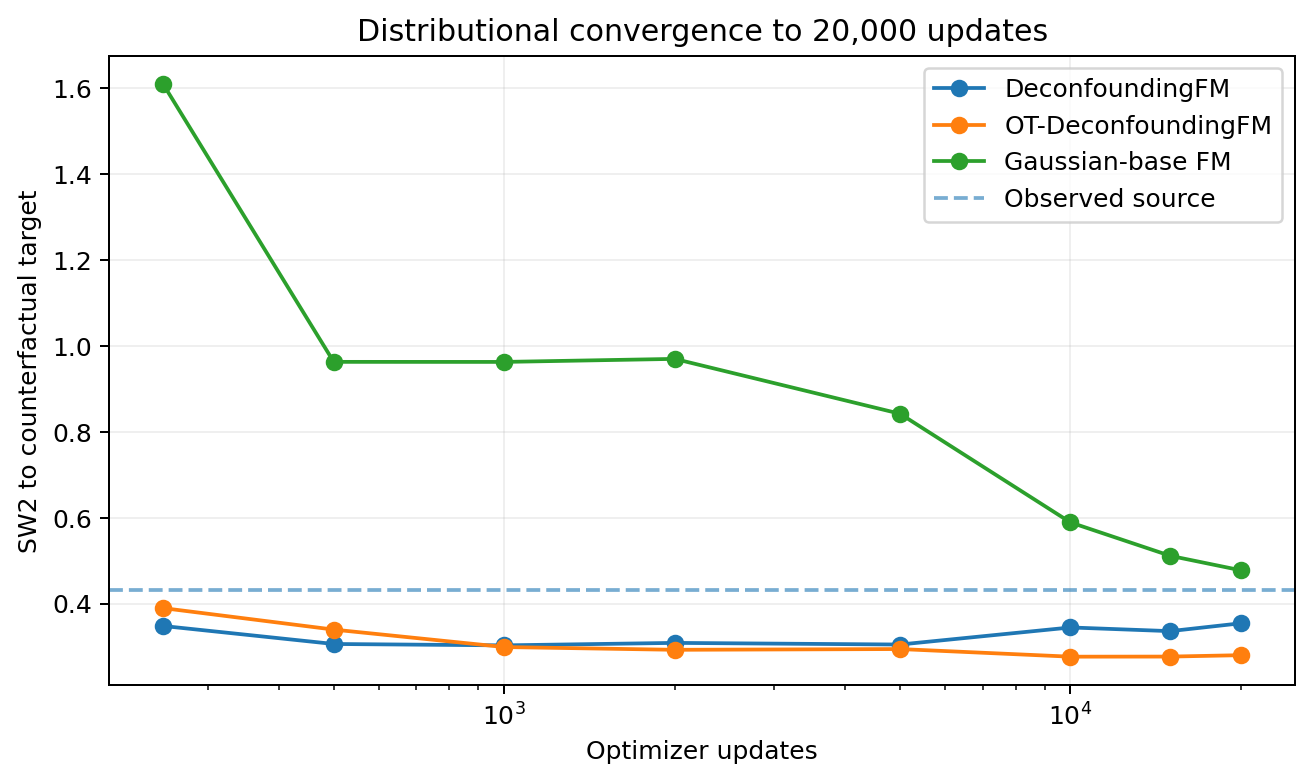

In [9]:
from copy import deepcopy


@torch.no_grad()
def checkpoint_sw2(model, base_samples):
    final_state = {
        key: value.detach().cpu().clone()
        for key, value in model.velocity_.state_dict().items()
    }
    values = []
    try:
        for step in CHECKPOINT_STEPS:
            model.velocity_.load_state_dict(model.model_.checkpoint_state_dicts_[step])
            generated = model.transform(base_samples, a=1).cpu()
            values.append(sliced_w2(generated, y_ref_eval))
    finally:
        model.velocity_.load_state_dict(final_state)
    return values


curve_decfm = checkpoint_sw2(decfm, y_source_eval)
curve_ot = checkpoint_sw2(ot_decfm, y_source_eval)
curve_gaussian = checkpoint_sw2(gaussian_fm, z_gaussian_eval)

print("updates      DeconfoundingFM   OT-DeconfoundingFM   Gaussian-base FM")
for step, d, o, g in zip(CHECKPOINT_STEPS, curve_decfm, curve_ot, curve_gaussian):
    print(f"{step:>6,}      {d:>8.3f}           {o:>8.3f}           {g:>8.3f}")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(CHECKPOINT_STEPS, curve_decfm, marker="o", label="DeconfoundingFM")
ax.plot(CHECKPOINT_STEPS, curve_ot, marker="o", label="OT-DeconfoundingFM")
ax.plot(CHECKPOINT_STEPS, curve_gaussian, marker="o", label="Gaussian-base FM")
ax.axhline(sw2_source, linestyle="--", alpha=0.6, label="Observed source")
ax.set_xscale("log")
ax.set_xlabel("Optimizer updates")
ax.set_ylabel("SW2 to counterfactual target")
ax.set_title("Distributional convergence")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()


## 6. Visualize the learned transports

The OT variant is intended to target a lower-energy deconfounding transport in dimensions greater than one. We therefore show both the trajectories and a simple kinetic-energy diagnostic evaluated on the same observed arm-1 starting points.


In [10]:
@torch.no_grad()
def trace_flow(model, y0, a=1, steps=24):
    y = y0.clone().to(model.device)
    trajectory = [y.cpu()]
    dt = 1.0 / steps
    context = torch.full((len(y), 1), float(a), device=model.device)
    for k in range(steps):
        t0 = torch.full((len(y),), k * dt, device=model.device)
        tmid = torch.full((len(y),), (k + 0.5) * dt, device=model.device)
        k1 = model.velocity_(y, t0, context)
        ymid = y + 0.5 * dt * k1
        k2 = model.velocity_(ymid, tmid, context)
        y = y + dt * k2
        trajectory.append(y.cpu())
    return torch.stack(trajectory)


n_paths = 28
path_generator = torch.Generator().manual_seed(321)
source_paths = Y1_observed[torch.randperm(len(Y1_observed), generator=path_generator)[:n_paths]]
gaussian_generator = torch.Generator().manual_seed(654)
gaussian_paths = torch.randn(n_paths, 2, generator=gaussian_generator)
traj_decfm = trace_flow(decfm, source_paths)
traj_ot = trace_flow(ot_decfm, source_paths)
traj_gaussian = trace_flow(gaussian_fm, gaussian_paths)

# Same empirical source points for the two deconfounding flows.
ctx = torch.ones(len(source_paths), 1, device=decfm.device)
energy_decfm = path_energy_midpoint(
    decfm.velocity_, source_paths.to(decfm.device), context=ctx, steps=32
).item()
energy_ot = path_energy_midpoint(
    ot_decfm.velocity_, source_paths.to(ot_decfm.device), context=ctx.to(ot_decfm.device), steps=32
).item()

print(f"Mean path energy, DeconfoundingFM:    {energy_decfm:.3f}")
print(f"Mean path energy, OT-DeconfoundingFM: {energy_ot:.3f}")


Mean path energy, DeconfoundingFM:    8.152
Mean path energy, OT-DeconfoundingFM: 0.116


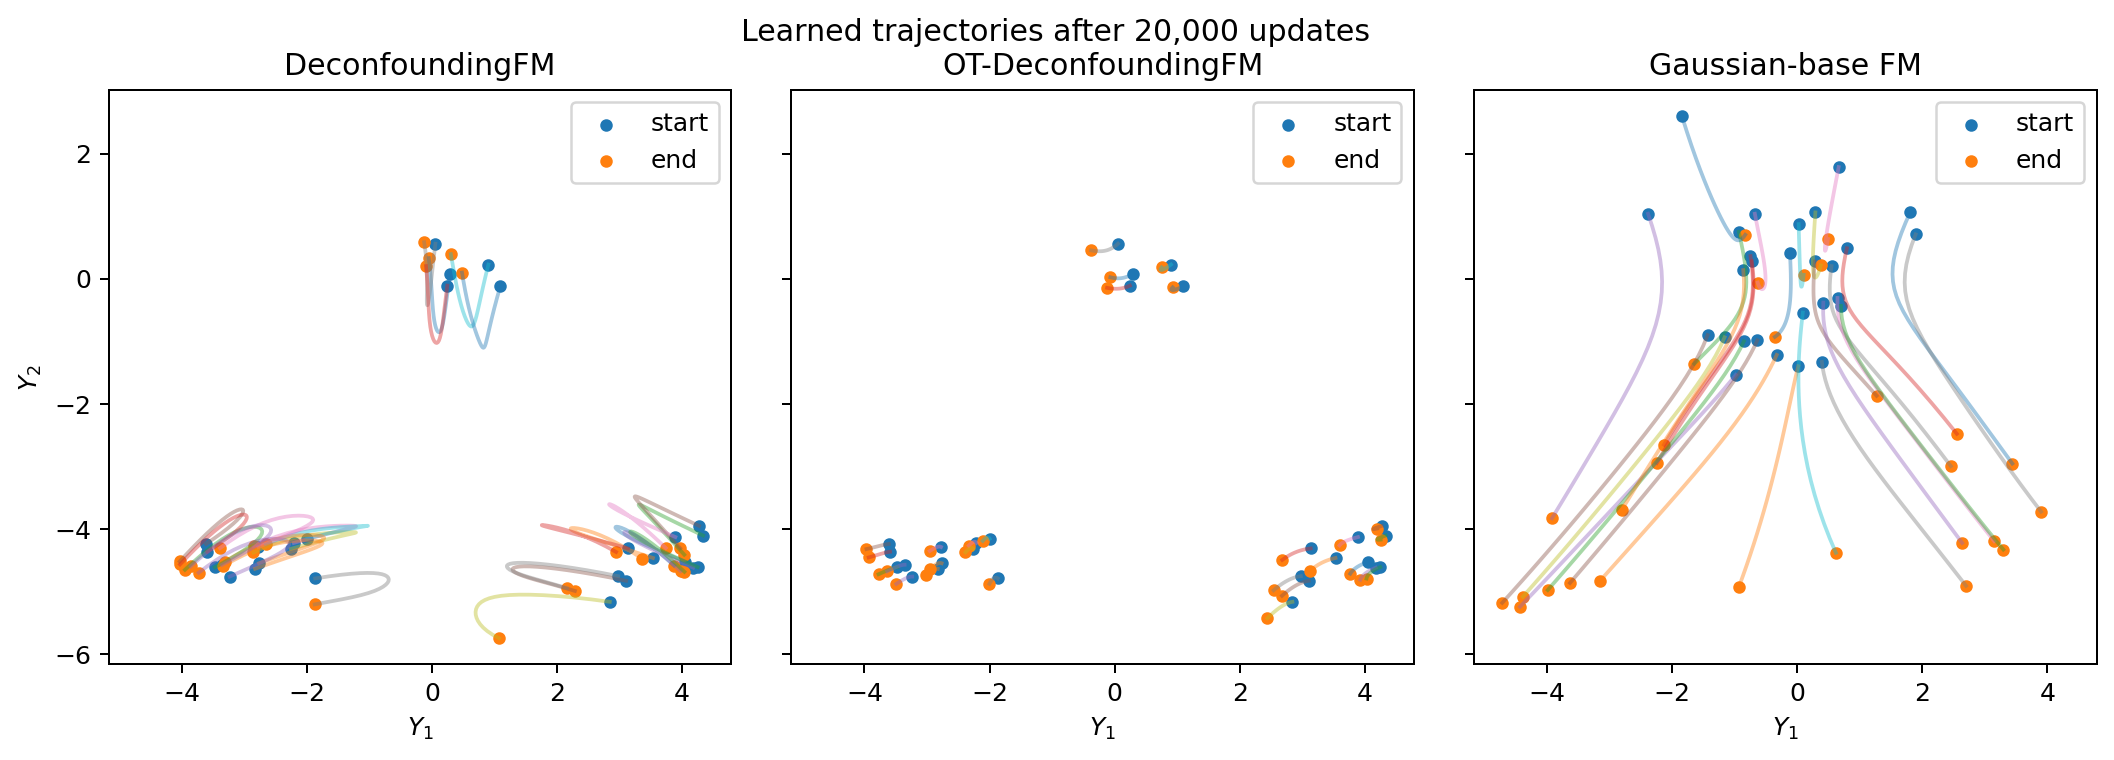

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
trajectories = [
    (traj_decfm, "DeconfoundingFM"),
    (traj_ot, "OT-DeconfoundingFM"),
    (traj_gaussian, "Gaussian-base FM"),
]
for ax, (traj, title) in zip(axes, trajectories):
    for j in range(n_paths):
        ax.plot(traj[:, j, 0], traj[:, j, 1], alpha=0.42)
    ax.scatter(traj[0, :, 0], traj[0, :, 1], s=16, label="start")
    ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=16, label="end")
    ax.set_title(title)
    ax.set_xlabel(r"$Y_1$")
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
axes[0].set_ylabel(r"$Y_2$")
plt.tight_layout()
plt.show()


## Takeaway

The observational base already contains all three mixture components, whereas the Gaussian baseline begins with mass concentrated around the central mode and must learn the two distant modes from scratch. OT-DeconfoundingFM additionally uses a minibatch entropic-OT coupling to target a much lower-energy correction between the observational and counterfactual distributions.
